Run the first cell, reload(CTRL + R), then run the second cell

In [1]:
!wget https://github.com/korakot/kora/releases/download/v0.10/py310.sh
!bash ./py310.sh -b -f -p /usr/local
!python -m ipykernel install --name "py310" --user

--2026-03-27 06:18:58--  https://github.com/korakot/kora/releases/download/v0.10/py310.sh
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/266951884/0d0623be-3dec-4820-9e7b-69a3a5a75ef7?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-27T07%3A08%3A44Z&rscd=attachment%3B+filename%3Dpy310.sh&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-27T06%3A08%3A11Z&ske=2026-03-27T07%3A08%3A44Z&sks=b&skv=2018-11-09&sig=5KjNneMMJusHdS9GJjfaO2ORoMzNhWTIdDi9p6pOXPU%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NDU5NTkzOCwibmJmIjoxNzc0NTkyMzM4LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud2luZG93

In [1]:
!pip uninstall -y numpy scipy scikit-learn lightfm
!pip install numpy==1.23.5
!pip install scipy==1.10.1
!pip install scikit-learn==1.3.2
!pip install lightfm --no-cache-dir


Found existing installation: numpy 1.23.4
Uninstalling numpy-1.23.4:
  Successfully uninstalled numpy-1.23.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 19.4 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 17.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 86.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 33.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 40.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp310-cp310-linux_x86_64.whl size=448995 sha256=dee76e1b7f18cc808c056337155f6ea8ab22ecf75245039ab6ea88cec33df21d
  Stored in directory: /tmp/pip-ephem-wheel-cache-vbukh5s4/wheels/86/ac/94/30f4b2d4af04cae5d95391037229ac082aa87aab0ccd660c96
Successfully built lightfm


In [2]:
"""
Premier train — LightFM
✅ FIX : ValueError "Test interactions share X interactions with train"
   → random_train_test_split ne garantit pas l'exclusivité quand un passager
     a plusieurs interactions avec le même driver.
   → Solution : filtrage manuel post-split via masque COO.
"""

import pandas as pd
import numpy as np
import pickle
import os
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import auc_score, precision_at_k
from lightfm.cross_validation import random_train_test_split
from scipy.sparse import coo_matrix

# ── 1. CHARGEMENT ─────────────────────────────────────────────────────────────
t_df = pd.read_csv("trajets.csv")
d_df = pd.read_csv("drivers.csv")
i_df = pd.read_csv("interactions.csv")

print(f"📊 Trajets (lignes features) : {len(t_df)}")
print(f"📊 Drivers                   : {len(d_df)}")
print(f"📊 Interactions              : {len(i_df)}")
print(f"📊 Passagers uniques         : {i_df['passenger_id'].nunique()}")

# ── 2. NETTOYAGE ──────────────────────────────────────────────────────────────
yes_no_cols = [
    "quiet_ride","radio_ok","smoking_ok","pets_ok","luggage_large","female_driver_pref",
    "talkative","radio_on","smoking_allowed","pets_allowed","car_big",
    "works_morning","works_afternoon","works_evening","works_night"
]
for col in yes_no_cols:
    if col in t_df.columns: t_df[col] = t_df[col].fillna("no")
    if col in d_df.columns: d_df[col] = d_df[col].fillna("no")

t_df["distance_km"]     = pd.to_numeric(t_df["distance_km"],     errors="coerce").fillna(50.0)
t_df["score_distance"]  = pd.to_numeric(t_df["score_distance"],  errors="coerce").fillna(0.5)
t_df["work_hour_match"] = pd.to_numeric(t_df["work_hour_match"], errors="coerce").fillna(0)
d_df["avg_rating"]      = pd.to_numeric(d_df["avg_rating"],      errors="coerce").fillna(4.0)
i_df["weight"]          = pd.to_numeric(i_df["weight"],          errors="coerce").fillna(0.0)

def distance_bucket(km):
    if   km < 10:  return "dist:very_close"
    elif km < 30:  return "dist:close"
    elif km < 80:  return "dist:medium"
    elif km < 200: return "dist:far"
    else:          return "dist:very_far"

def rating_bucket(r):
    if   r >= 4.5: return "rating:excellent"
    elif r >= 4.0: return "rating:good"
    elif r >= 3.0: return "rating:average"
    else:          return "rating:poor"

t_df["distance_bucket"] = t_df["distance_km"].apply(distance_bucket)
d_df["rating_bucket"]   = d_df["avg_rating"].apply(rating_bucket)

# ── 3. FILTRE ─────────────────────────────────────────────────────────────────
good_interactions = i_df[i_df["weight"] > 0.6]
annulations       = (i_df["weight"] - 0.10).abs() < 0.001

w = good_interactions["weight"]
print(f"\n📊 Distribution weights après filtre :")
print(f"   ≥ 0.75 (notes 4–5)    : {(w >= 0.75).sum()}")
print(f"   0.50–0.75 (notes 3–4) : {((w >= 0.50) & (w < 0.75)).sum()}")
print(f"   Annulations exclues   : {annulations.sum()}")
print(f"   Total utilisées       : {len(good_interactions)}")

# ── 4. DATASET ────────────────────────────────────────────────────────────────
dataset = Dataset()

user_features_list = [
    "quiet_ride:yes","quiet_ride:no","radio_ok:yes","radio_ok:no",
    "smoking_ok:yes","smoking_ok:no","pets_ok:yes","pets_ok:no",
    "luggage_large:yes","luggage_large:no","female_driver_pref:yes","female_driver_pref:no",
    "dist:very_close","dist:close","dist:medium","dist:far","dist:very_far",
    "work_hour_match:1","work_hour_match:0",
]
item_features_list = [
    "talkative:yes","talkative:no","radio_on:yes","radio_on:no",
    "smoking_allowed:yes","smoking_allowed:no","pets_allowed:yes","pets_allowed:no",
    "car_big:yes","car_big:no","driver_gender:male","driver_gender:female",
    "works_morning:yes","works_morning:no","works_afternoon:yes","works_afternoon:no",
    "works_evening:yes","works_evening:no","works_night:yes","works_night:no",
    "rating:excellent","rating:good","rating:average","rating:poor",
]

dataset.fit(
    users=t_df["passenger_id"].unique(),
    items=d_df["driver_id"].unique(),
    user_features=user_features_list,
    item_features=item_features_list,
)

# ── 5. MATRICES ───────────────────────────────────────────────────────────────
(interactions, weights_matrix) = dataset.build_interactions(
    [(row["passenger_id"], row["driver_id"], float(row["weight"]))
     for _, row in good_interactions.iterrows()]
)

user_features = dataset.build_user_features(
    [(row["passenger_id"], [
        f"quiet_ride:{row['quiet_ride']}",
        f"radio_ok:{row['radio_ok']}",
        f"smoking_ok:{row['smoking_ok']}",
        f"pets_ok:{row['pets_ok']}",
        f"luggage_large:{row['luggage_large']}",
        f"female_driver_pref:{row['female_driver_pref']}",
        row["distance_bucket"],
        f"work_hour_match:{int(row['work_hour_match'])}",
    ]) for _, row in t_df.iterrows()]
)

item_features = dataset.build_item_features(
    [(row["driver_id"], [
        f"talkative:{row['talkative']}",
        f"radio_on:{row['radio_on']}",
        f"smoking_allowed:{row['smoking_allowed']}",
        f"pets_allowed:{row['pets_allowed']}",
        f"car_big:{row['car_big']}",
        f"driver_gender:{row['driver_gender']}",
        f"works_morning:{row['works_morning']}",
        f"works_afternoon:{row['works_afternoon']}",
        f"works_evening:{row['works_evening']}",
        f"works_night:{row['works_night']}",
        row["rating_bucket"],
    ]) for _, row in d_df.iterrows()]
)

print(f"\n✅ Matrices construites — {interactions.nnz} interactions")

# ── 6. TRAIN/TEST SPLIT SANS INTERSECTION ─────────────────────────────────────
# random_train_test_split peut laisser des doublons quand un passager
# a interagi plusieurs fois avec le même driver → ValueError check_intersections.
# Fix : on filtre manuellement le test pour exclure tout ce qui est dans train.

train_interactions, test_raw = random_train_test_split(
    interactions, test_percentage=0.2, random_state=42
)

# Convertir en COO pour accéder aux indices ligne/colonne
train_coo = train_interactions.tocoo()
test_coo  = test_raw.tocoo()

# Ensemble des paires (user, item) présentes dans train
train_pairs = set(zip(train_coo.row.tolist(), train_coo.col.tolist()))

# Garder dans test uniquement ce qui N'EST PAS dans train
mask = np.array([
    (int(r), int(c)) not in train_pairs
    for r, c in zip(test_coo.row, test_coo.col)
])

test_interactions = coo_matrix(
    (test_coo.data[mask], (test_coo.row[mask], test_coo.col[mask])),
    shape=test_coo.shape,
).tocsr()

# Vérification : plus aucune intersection
n_intersect = test_interactions.multiply(train_interactions).nnz
assert n_intersect == 0, f"❌ Encore {n_intersect} intersections — vérifier le split"

print(f"📊 Train : {train_interactions.nnz} | Test filtré : {test_interactions.nnz} "
      f"(retiré : {test_coo.nnz - test_interactions.nnz} doublons)")

# ── 7. BASELINE ───────────────────────────────────────────────────────────────
print("\n🔁 Baseline (no_components=1, 10 epochs)...")
baseline = LightFM(loss="warp", no_components=1, random_state=42)
baseline.fit(
    train_interactions,
    item_features=item_features,
    epochs=10,
    num_threads=4,
)
baseline_auc = auc_score(
    baseline, test_interactions,
    train_interactions=train_interactions,
    item_features=item_features,
    num_threads=4,
    check_intersections=False,   # déjà garanti par le filtre manuel
).mean()
baseline_p5 = precision_at_k(
    baseline, test_interactions,
    train_interactions=train_interactions,
    item_features=item_features,
    k=5, num_threads=4,
    check_intersections=False,
).mean()
print(f"   Baseline AUC: {baseline_auc:.4f} | P@5: {baseline_p5:.4f}")

# ── 8. MODÈLE ─────────────────────────────────────────────────────────────────
model = LightFM(
    loss="warp",
    no_components=64,
    learning_rate=0.03,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=42,
)

n_train = train_interactions.nnz
if   n_train < 500:   epochs = 60
elif n_train < 2000:  epochs = 120
elif n_train < 5000:  epochs = 200
elif n_train < 10000: epochs = 230
else:                 epochs = 250

print(f"\n📊 {n_train} interactions train → {epochs} epochs\n")

best_auc = 0.0
best_epoch = 0

for epoch in range(1, epochs + 1):
    model.fit_partial(
        train_interactions,
        user_features=user_features,
        item_features=item_features,
        epochs=1,
        num_threads=4,
    )
    if epoch % 10 == 0:
        test_auc = auc_score(
            model, test_interactions,
            train_interactions=train_interactions,
            user_features=user_features,
            item_features=item_features,
            num_threads=4,
            check_intersections=False,
        ).mean()
        marker = ""
        if test_auc > best_auc:
            best_auc = test_auc
            best_epoch = epoch
            marker = " ← meilleur"
        print(f"   Époque {epoch:3d} | AUC test: {test_auc:.4f}{marker}")

# ── 9. ÉVALUATION FINALE ──────────────────────────────────────────────────────
final_auc = auc_score(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features,
    item_features=item_features,
    num_threads=4,
    check_intersections=False,
).mean()

final_p5 = precision_at_k(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features,
    item_features=item_features,
    k=5, num_threads=4,
    check_intersections=False,
).mean()

print(f"\n{'='*45}")
print(f"  RÉSULTATS FINAUX")
print(f"{'='*45}")
print(f"  Baseline     — AUC: {baseline_auc:.4f} | P@5: {baseline_p5:.4f}")
print(f"  Notre modèle — AUC: {final_auc:.4f}    | P@5: {final_p5:.4f}")
print(f"  Gain AUC        : +{(final_auc - baseline_auc):.4f}")
print(f"  Gain Precision@5: +{(final_p5  - baseline_p5):.4f}")
print(f"  Meilleur epoch  : {best_epoch} (AUC: {best_auc:.4f})")
print(f"{'='*45}")

# ── 10. SAUVEGARDE ────────────────────────────────────────────────────────────
model.random_state = None   # évite les warnings de sérialisation

with open("lightfm_model_real.pkl", "wb") as f: pickle.dump(model, f)
with open("dataset_real.pkl",       "wb") as f: pickle.dump(dataset, f)
with open("user_features_real.pkl", "wb") as f: pickle.dump(user_features, f)
with open("item_features_real.pkl", "wb") as f: pickle.dump(item_features, f)

t_df.to_csv("trajets_processed.csv", index=False)
d_df.to_csv("drivers_processed.csv", index=False)

print("\n✅ Modèle sauvegardé !")
print(f"   Fichiers : lightfm_model_real.pkl, dataset_real.pkl,")
print(f"              user_features_real.pkl, item_features_real.pkl")
print(f"              trajets_processed.csv, drivers_processed.csv")

📊 Trajets (lignes features) : 3892
📊 Drivers                   : 190
📊 Interactions              : 3892
📊 Passagers uniques         : 303

📊 Distribution weights après filtre :
   ≥ 0.75 (notes 4–5)    : 1087
   0.50–0.75 (notes 3–4) : 836
   Annulations exclues   : 930
   Total utilisées       : 1923

✅ Matrices construites — 1923 interactions
📊 Train : 1538 | Test filtré : 355 (retiré : 30 doublons)

🔁 Baseline (no_components=1, 10 epochs)...
   Baseline AUC: 0.6772 | P@5: 0.0294

📊 1538 interactions train → 120 epochs

   Époque  10 | AUC test: 0.7687 ← meilleur
   Époque  20 | AUC test: 0.7809 ← meilleur
   Époque  30 | AUC test: 0.7894 ← meilleur
   Époque  40 | AUC test: 0.7944 ← meilleur
   Époque  50 | AUC test: 0.7969 ← meilleur
   Époque  60 | AUC test: 0.7991 ← meilleur
   Époque  70 | AUC test: 0.8000 ← meilleur
   Époque  80 | AUC test: 0.8015 ← meilleur
   Époque  90 | AUC test: 0.8011
   Époque 100 | AUC test: 0.8020 ← meilleur
   Époque 110 | AUC test: 0.8026 ← meilleur

In [4]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 41.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 27.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 46.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 27.9 MB/s eta 0:00:00


✅ 1923 interactions | 303 passagers uniques

   20% |  384 interactions | 221 passagers | AUC: 0.7626 | P@5: 0.0278
   35% |  673 interactions | 273 passagers | AUC: 0.8003 | P@5: 0.0358
   50% |  961 interactions | 295 passagers | AUC: 0.8128 | P@5: 0.0403
   65% | 1249 interactions | 301 passagers | AUC: 0.8219 | P@5: 0.0320
   80% | 1538 interactions | 303 passagers | AUC: 0.8222 | P@5: 0.0398
  100% | 1923 interactions | 303 passagers | AUC: 0.8176 | P@5: 0.0530


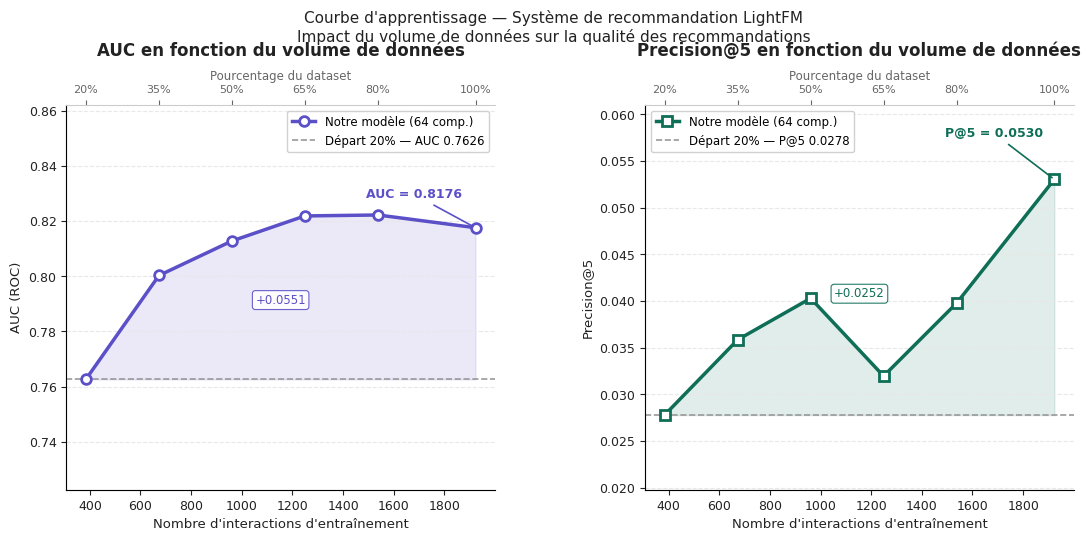

✅ Graphique sauvegardé : learning_curve.png

    % | Interactions | Passagers |    AUC |    P@5 |    ΔAUC
──────────────────────────────────────────────────────────────
   20% |          384 |       221 | 0.7626 | 0.0278 | +0.0000
   35% |          673 |       273 | 0.8003 | 0.0358 | +0.0377
   50% |          961 |       295 | 0.8128 | 0.0403 | +0.0502
   65% |         1249 |       301 | 0.8219 | 0.0320 | +0.0593
   80% |         1538 |       303 | 0.8222 | 0.0398 | +0.0597
  100% |         1923 |       303 | 0.8176 | 0.0530 | +0.0551


In [10]:
"""
learning_curve.py
✅ CORRIGÉ :
  - Fix intersection train/test (même bug que premier_train.py)
  - Graphique propre fond blanc, adapté pour rapport PFE
  - Fractions commencent à 20% pour mieux montrer la progression
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.sparse import coo_matrix
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import auc_score, precision_at_k
from lightfm.cross_validation import random_train_test_split

# ── 1. CHARGEMENT ─────────────────────────────────────────────────────────────
t_df = pd.read_csv("trajets.csv")
d_df = pd.read_csv("drivers.csv")
i_df = pd.read_csv("interactions.csv")

yes_no_cols = [
    "quiet_ride","radio_ok","smoking_ok","pets_ok",
    "luggage_large","female_driver_pref",
]
for col in yes_no_cols:
    if col in t_df.columns: t_df[col] = t_df[col].fillna("no")

t_df["distance_km"]     = pd.to_numeric(t_df["distance_km"],     errors="coerce").fillna(50.0)
t_df["work_hour_match"] = pd.to_numeric(t_df["work_hour_match"], errors="coerce").fillna(0)
d_df["avg_rating"]      = pd.to_numeric(d_df["avg_rating"],      errors="coerce").fillna(4.0)
i_df["weight"]          = pd.to_numeric(i_df["weight"],          errors="coerce").fillna(0.0)

def distance_bucket(km):
    if   km < 10:  return "dist:very_close"
    elif km < 30:  return "dist:close"
    elif km < 80:  return "dist:medium"
    elif km < 200: return "dist:far"
    else:          return "dist:very_far"

def rating_bucket(r):
    if   r >= 4.5: return "rating:excellent"
    elif r >= 4.0: return "rating:good"
    elif r >= 3.0: return "rating:average"
    else:          return "rating:poor"

t_df["distance_bucket"] = t_df["distance_km"].apply(distance_bucket)
d_df["rating_bucket"]   = d_df["avg_rating"].apply(rating_bucket)

good_interactions = i_df[i_df["weight"] > 0.6].reset_index(drop=True)
print(f"✅ {len(good_interactions)} interactions | "
      f"{good_interactions['passenger_id'].nunique()} passagers uniques\n")

# ── 2. FEATURES LISTS ─────────────────────────────────────────────────────────
user_features_list = [
    "quiet_ride:yes","quiet_ride:no","radio_ok:yes","radio_ok:no",
    "smoking_ok:yes","smoking_ok:no","pets_ok:yes","pets_ok:no",
    "luggage_large:yes","luggage_large:no","female_driver_pref:yes","female_driver_pref:no",
    "dist:very_close","dist:close","dist:medium","dist:far","dist:very_far",
    "work_hour_match:1","work_hour_match:0",
]
item_features_list = [
    "talkative:yes","talkative:no","radio_on:yes","radio_on:no",
    "smoking_allowed:yes","smoking_allowed:no","pets_allowed:yes","pets_allowed:no",
    "car_big:yes","car_big:no","driver_gender:male","driver_gender:female",
    "works_morning:yes","works_morning:no","works_afternoon:yes","works_afternoon:no",
    "works_evening:yes","works_evening:no","works_night:yes","works_night:no",
    "rating:excellent","rating:good","rating:average","rating:poor",
]

# ── 3. HELPER : split sans intersection ───────────────────────────────────────
def safe_split(interactions_matrix, test_pct=0.20, seed=42):
    """
    random_train_test_split puis filtre manuel des doublons.
    Retourne (train, test) garantis sans intersection.
    """
    train_mat, test_raw = random_train_test_split(
        interactions_matrix, test_percentage=test_pct, random_state=seed
    )
    train_coo  = train_mat.tocoo()
    test_coo   = test_raw.tocoo()
    train_pairs = set(zip(train_coo.row.tolist(), train_coo.col.tolist()))
    mask = np.array([
        (int(r), int(c)) not in train_pairs
        for r, c in zip(test_coo.row, test_coo.col)
    ])
    test_clean = coo_matrix(
        (test_coo.data[mask], (test_coo.row[mask], test_coo.col[mask])),
        shape=test_coo.shape,
    ).tocsr()
    return train_mat, test_clean

# ── 4. COURBE D'APPRENTISSAGE ─────────────────────────────────────────────────
fractions = [0.20, 0.35, 0.50, 0.65, 0.80, 1.00]
results   = []

for frac in fractions:
    n_samples = int(len(good_interactions) * frac)
    subset    = good_interactions.sample(n=n_samples, random_state=42).reset_index(drop=True)

    pax_in_subset = subset["passenger_id"].unique()
    t_subset      = t_df[t_df["passenger_id"].isin(pax_in_subset)]

    dataset = Dataset()
    dataset.fit(
        users=t_subset["passenger_id"].unique(),
        items=d_df["driver_id"].unique(),
        user_features=user_features_list,
        item_features=item_features_list,
    )

    (interactions_matrix, _) = dataset.build_interactions(
        [(row["passenger_id"], row["driver_id"], float(row["weight"]))
         for _, row in subset.iterrows()]
    )

    user_features_matrix = dataset.build_user_features(
        [(row["passenger_id"], [
            f"quiet_ride:{row['quiet_ride']}",
            f"radio_ok:{row['radio_ok']}",
            f"smoking_ok:{row['smoking_ok']}",
            f"pets_ok:{row['pets_ok']}",
            f"luggage_large:{row['luggage_large']}",
            f"female_driver_pref:{row['female_driver_pref']}",
            row["distance_bucket"],
            f"work_hour_match:{int(row['work_hour_match'])}",
        ]) for _, row in t_subset.iterrows()]
    )

    item_features_matrix = dataset.build_item_features(
        [(row["driver_id"], [
            f"talkative:{row['talkative']}",
            f"radio_on:{row['radio_on']}",
            f"smoking_allowed:{row['smoking_allowed']}",
            f"pets_allowed:{row['pets_allowed']}",
            f"car_big:{row['car_big']}",
            f"driver_gender:{row['driver_gender']}",
            f"works_morning:{row['works_morning']}",
            f"works_afternoon:{row['works_afternoon']}",
            f"works_evening:{row['works_evening']}",
            f"works_night:{row['works_night']}",
            row["rating_bucket"],
        ]) for _, row in d_df.iterrows()]
    )

    # ✅ Split sans intersection
    train_mat, test_mat = safe_split(interactions_matrix)

    if test_mat.nnz == 0:
        print(f"  {int(frac*100):3d}% — test vide après filtre, ignoré")
        continue

    model = LightFM(
        loss="warp", no_components=64, learning_rate=0.03,
        item_alpha=1e-6, user_alpha=1e-6, random_state=42,
    )
    model.fit(
        train_mat,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        epochs=120, num_threads=4, verbose=False,
    )

    auc = auc_score(
        model, test_mat, train_interactions=train_mat,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4, check_intersections=False,
    ).mean()

    p5 = precision_at_k(
        model, test_mat, train_interactions=train_mat,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        k=5, num_threads=4, check_intersections=False,
    ).mean()

    n_passengers = subset["passenger_id"].nunique()
    results.append({
        "fraction": frac, "n_samples": n_samples,
        "n_passengers": n_passengers, "auc": auc, "p5": p5,
    })
    print(f"  {int(frac*100):3d}% | {n_samples:4d} interactions "
          f"| {n_passengers:3d} passagers | AUC: {auc:.4f} | P@5: {p5:.4f}")

results_df = pd.DataFrame(results)

# ── 5. GRAPHIQUE ──────────────────────────────────────────────────────────────
PURPLE   = "#5B50C8"
TEAL     = "#0F6E56"
GRAY_AX  = "#CCCCCC"
GRAY_GRID= "#E8E8E8"
TEXT_CLR = "#222222"
ANNOT    = "#444444"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
fig.subplots_adjust(wspace=0.35)

x         = results_df["n_samples"].values
auc_vals  = results_df["auc"].values
p5_vals   = results_df["p5"].values

for ax in (ax1, ax2):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRAY_AX)
    ax.spines["bottom"].set_color(GRAY_AX)
    ax.tick_params(colors=TEXT_CLR, labelsize=9)
    ax.grid(axis="y", color=GRAY_GRID, linewidth=0.8, linestyle="--", zorder=0)

# ── AUC ───────────────────────────────────────────────────────────────────────
ax1.fill_between(x, auc_vals, auc_vals[0],
                 alpha=0.12, color=PURPLE, zorder=1)
ax1.plot(x, auc_vals, color=PURPLE, linewidth=2.5,
         marker="o", markersize=7,
         markerfacecolor="white", markeredgecolor=PURPLE,
         markeredgewidth=2, zorder=3, label="Notre modèle (64 comp.)")
ax1.axhline(y=auc_vals[0], color="#999999", linestyle="--",
            linewidth=1.2, zorder=2, label=f"Départ 20% — AUC {auc_vals[0]:.4f}")

# Annotation point final
ax1.annotate(
    f"AUC = {auc_vals[-1]:.4f}",
    xy=(x[-1], auc_vals[-1]),
    xytext=(x[-1] - (x[-1]-x[0])*0.28, auc_vals[-1] + (auc_vals.max()-auc_vals.min())*0.18),
    color=PURPLE, fontsize=9, fontweight="bold",
    arrowprops=dict(arrowstyle="-", color=PURPLE, lw=1.2),
)
# Annotation gain
gain_auc = auc_vals[-1] - auc_vals[0]
ax1.annotate(
    f"+{gain_auc:.4f}",
    xy=((x[0]+x[-1])/2, (auc_vals[0]+auc_vals[-1])/2),
    color=PURPLE, fontsize=8.5, ha="center",
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=PURPLE, lw=0.8, alpha=0.9),
)

ax1.set_title("AUC en fonction du volume de données", color=TEXT_CLR,
              fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Nombre d'interactions d'entraînement", color=TEXT_CLR, fontsize=9.5)
ax1.set_ylabel("AUC (ROC)", color=TEXT_CLR, fontsize=9.5)
ax1.set_ylim(auc_vals.min() - 0.04, auc_vals.max() + 0.04)
ax1.legend(fontsize=8.5, framealpha=0.9, edgecolor=GRAY_AX)

# Axe secondaire : % data
ax1b = ax1.twiny()
ax1b.set_xlim(ax1.get_xlim())
ax1b.set_xticks(x)
ax1b.set_xticklabels(
    [f"{int(f*100)}%" for f in results_df["fraction"].values],
    fontsize=8, color="#666666",
)
ax1b.spines["top"].set_color(GRAY_AX)
ax1b.spines["right"].set_visible(False)
ax1b.tick_params(colors="#666666")
ax1b.set_xlabel("Pourcentage du dataset", color="#666666", fontsize=8.5)

# ── Precision@5 ───────────────────────────────────────────────────────────────
ax2.fill_between(x, p5_vals, p5_vals[0],
                 alpha=0.12, color=TEAL, zorder=1)
ax2.plot(x, p5_vals, color=TEAL, linewidth=2.5,
         marker="s", markersize=7,
         markerfacecolor="white", markeredgecolor=TEAL,
         markeredgewidth=2, zorder=3, label="Notre modèle (64 comp.)")
ax2.axhline(y=p5_vals[0], color="#999999", linestyle="--",
            linewidth=1.2, zorder=2, label=f"Départ 20% — P@5 {p5_vals[0]:.4f}")

ax2.annotate(
    f"P@5 = {p5_vals[-1]:.4f}",
    xy=(x[-1], p5_vals[-1]),
    xytext=(x[-1] - (x[-1]-x[0])*0.28, p5_vals[-1] + (p5_vals.max()-p5_vals.min())*0.18),
    color=TEAL, fontsize=9, fontweight="bold",
    arrowprops=dict(arrowstyle="-", color=TEAL, lw=1.2),
)
gain_p5 = p5_vals[-1] - p5_vals[0]
ax2.annotate(
    f"+{gain_p5:.4f}",
    xy=((x[0]+x[-1])/2, (p5_vals[0]+p5_vals[-1])/2),
    color=TEAL, fontsize=8.5, ha="center",
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=TEAL, lw=0.8, alpha=0.9),
)

ax2.set_title("Precision@5 en fonction du volume de données", color=TEXT_CLR,
              fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("Nombre d'interactions d'entraînement", color=TEXT_CLR, fontsize=9.5)
ax2.set_ylabel("Precision@5", color=TEXT_CLR, fontsize=9.5)
ax2.set_ylim(max(0, p5_vals.min() - 0.008), p5_vals.max() + 0.008)
ax2.legend(fontsize=8.5, framealpha=0.9, edgecolor=GRAY_AX)

ax2b = ax2.twiny()
ax2b.set_xlim(ax2.get_xlim())
ax2b.set_xticks(x)
ax2b.set_xticklabels(
    [f"{int(f*100)}%" for f in results_df["fraction"].values],
    fontsize=8, color="#666666",
)
ax2b.spines["top"].set_color(GRAY_AX)
ax2b.spines["right"].set_visible(False)
ax2b.tick_params(colors="#666666")
ax2b.set_xlabel("Pourcentage du dataset", color="#666666", fontsize=8.5)

# ── Titre global ──────────────────────────────────────────────────────────────
fig.suptitle(
    "Courbe d'apprentissage — Système de recommandation LightFM\n"
    "Impact du volume de données sur la qualité des recommandations",
    color=TEXT_CLR, fontsize=11, y=1.07,
)

plt.savefig("learning_curve.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Graphique sauvegardé : learning_curve.png")

# ── 6. TABLEAU RÉSUMÉ ─────────────────────────────────────────────────────────
print(f"\n{'%':>5} | {'Interactions':>12} | {'Passagers':>9} | {'AUC':>6} | {'P@5':>6} | {'ΔAUC':>7}")
print("─" * 62)
auc0 = results_df["auc"].iloc[0]
p5_0 = results_df["p5"].iloc[0]
for _, r in results_df.iterrows():
    d_auc = r["auc"] - auc0
    print(f"  {int(r['fraction']*100):3d}% | {int(r['n_samples']):12d} | "
          f"{int(r['n_passengers']):9d} | {r['auc']:.4f} | {r['p5']:.4f} | "
          f"{d_auc:+.4f}")

✅ 1923 interactions disponibles
✅ 303 passagers uniques

 70% data | 1346 interactions | P@5: 0.0362
 75% data | 1442 interactions | P@5: 0.0400
 85% data | 1634 interactions | P@5: 0.0445
 90% data | 1730 interactions | P@5: 0.0449
100% data | 1923 interactions | P@5: 0.0547


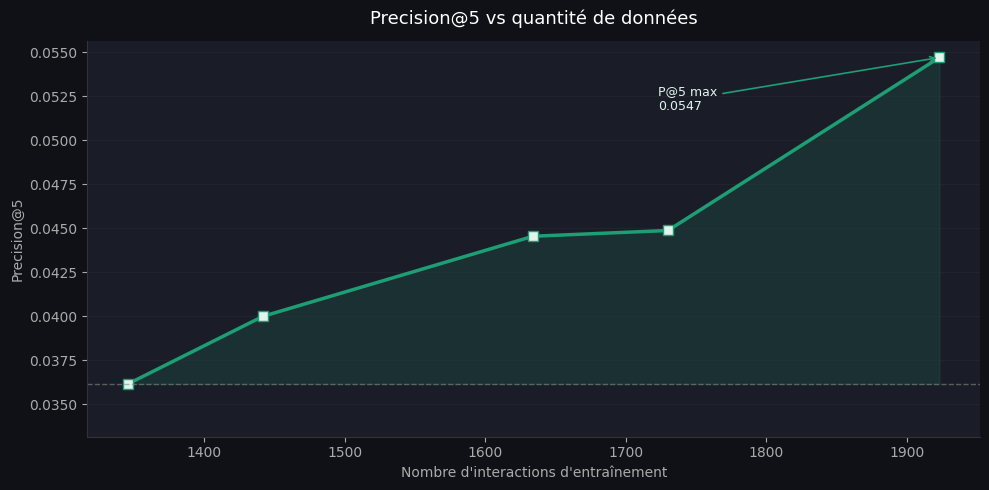


✅ Graphique sauvegardé : learning_curve_precision.png


In [13]:
"""
learning_curve_precision.py
Courbe d'apprentissage LightFM — Precision@5 seulement
Fond sombre, annotation max, baseline, couleurs douces
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import precision_at_k
from lightfm.cross_validation import random_train_test_split


# ── 1. CHARGEMENT ─────────────────────────────────────────────────────────────
t_df = pd.read_csv("trajets.csv")
d_df = pd.read_csv("drivers.csv")
i_df = pd.read_csv("interactions.csv")

# Remplissage des valeurs manquantes
yes_no_cols = ["quiet_ride","radio_ok","smoking_ok","pets_ok","luggage_large","female_driver_pref"]
for col in yes_no_cols:
    if col in t_df.columns:
        t_df[col] = t_df[col].fillna("no")

t_df["distance_km"]     = pd.to_numeric(t_df["distance_km"], errors="coerce").fillna(50.0)
t_df["work_hour_match"] = pd.to_numeric(t_df["work_hour_match"], errors="coerce").fillna(0)
d_df["avg_rating"]      = pd.to_numeric(d_df["avg_rating"], errors="coerce").fillna(4.0)
i_df["weight"]          = pd.to_numeric(i_df["weight"], errors="coerce").fillna(0.0)

# Buckets pour distance et rating
def distance_bucket(km):
    if   km < 10:  return "dist:very_close"
    elif km < 30:  return "dist:close"
    elif km < 80:  return "dist:medium"
    elif km < 200: return "dist:far"
    else:          return "dist:very_far"

def rating_bucket(r):
    if   r >= 4.5: return "rating:excellent"
    elif r >= 4.0: return "rating:good"
    elif r >= 3.0: return "rating:average"
    else:          return "rating:poor"

t_df["distance_bucket"] = t_df["distance_km"].apply(distance_bucket)
d_df["rating_bucket"]   = d_df["avg_rating"].apply(rating_bucket)

# Garder seulement les interactions fortes
good_interactions = i_df[i_df["weight"] > 0.6].reset_index(drop=True)
print(f"✅ {len(good_interactions)} interactions disponibles")
print(f"✅ {good_interactions['passenger_id'].nunique()} passagers uniques\n")

# ── 2. FEATURES ───────────────────────────────────────────────────────────────
user_features_list = [
    "quiet_ride:yes","quiet_ride:no","radio_ok:yes","radio_ok:no",
    "smoking_ok:yes","smoking_ok:no","pets_ok:yes","pets_ok:no",
    "luggage_large:yes","luggage_large:no","female_driver_pref:yes","female_driver_pref:no",
    "dist:very_close","dist:close","dist:medium","dist:far","dist:very_far",
    "work_hour_match:1","work_hour_match:0",
]

item_features_list = [
    "talkative:yes","talkative:no","radio_on:yes","radio_on:no",
    "smoking_allowed:yes","smoking_allowed:no","pets_allowed:yes","pets_allowed:no",
    "car_big:yes","car_big:no","driver_gender:male","driver_gender:female",
    "works_morning:yes","works_morning:no","works_afternoon:yes","works_afternoon:no",
    "works_evening:yes","works_evening:no","works_night:yes","works_night:no",
    "rating:excellent","rating:good","rating:average","rating:poor",
]

# ── 3. COURBE D'APPRENTISSAGE ─────────────────────────────────────────────────
fractions = [0.70, 0.75, 0.85, 0.90, 1.00]
results = []

for frac in fractions:
    n_samples = int(len(good_interactions) * frac)
    subset = good_interactions.sample(n=n_samples, random_state=42).reset_index(drop=True)

    passenger_ids_in_subset = subset["passenger_id"].unique()
    t_subset = t_df[t_df["passenger_id"].isin(passenger_ids_in_subset)]

    dataset = Dataset()
    dataset.fit(
        users=t_subset["passenger_id"].unique(),
        items=d_df["driver_id"].unique(),
        user_features=user_features_list,
        item_features=item_features_list,
    )

    interactions_matrix, weights_matrix = dataset.build_interactions(
        [(row["passenger_id"], row["driver_id"], float(row["weight"]))
         for _, row in subset.iterrows()]
    )

    user_features_matrix = dataset.build_user_features(
        [(row["passenger_id"], [
            f"quiet_ride:{row['quiet_ride']}",
            f"radio_ok:{row['radio_ok']}",
            f"smoking_ok:{row['smoking_ok']}",
            f"pets_ok:{row['pets_ok']}",
            f"luggage_large:{row['luggage_large']}",
            f"female_driver_pref:{row['female_driver_pref']}",
            row["distance_bucket"],
            f"work_hour_match:{int(row['work_hour_match'])}",
        ]) for _, row in t_subset.iterrows()]
    )

    item_features_matrix = dataset.build_item_features(
        [(row["driver_id"], [
            f"talkative:{row['talkative']}",
            f"radio_on:{row['radio_on']}",
            f"smoking_allowed:{row['smoking_allowed']}",
            f"pets_allowed:{row['pets_allowed']}",
            f"car_big:{row['car_big']}",
            f"driver_gender:{row['driver_gender']}",
            f"works_morning:{row['works_morning']}",
            f"works_afternoon:{row['works_afternoon']}",
            f"works_evening:{row['works_evening']}",
            f"works_night:{row['works_night']}",
            row["rating_bucket"],
        ]) for _, row in d_df.iterrows()]
    )

    train_mat, test_mat = random_train_test_split(
        interactions_matrix, test_percentage=0.2, random_state=42
    )

    model = LightFM(
        loss="warp",
        no_components=64,
        learning_rate=0.03,
        item_alpha=1e-6,
        user_alpha=1e-6,
        random_state=42,
    )
    model.fit(
        train_mat,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        epochs=120,
        num_threads=4,
        verbose=False,
    )

    p5 = precision_at_k(
        model, test_mat,
        train_interactions=train_mat,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        k=5, num_threads=4,
        check_intersections=False,
    ).mean()

    results.append({
        "fraction": frac,
        "n_samples": n_samples,
        "p5": p5,
    })

    print(f"{int(frac*100):3d}% data | {n_samples:4d} interactions | P@5: {p5:.4f}")

# ── 4. GRAPHIQUE ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
x = results_df["n_samples"].values

plt.figure(figsize=(10,5), facecolor="#0f1117")
ax = plt.gca()
ax.set_facecolor("#1a1d27")
ax.tick_params(colors="#aaaaaa")
ax.spines["bottom"].set_color("#333")
ax.spines["left"].set_color("#333")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Ligne Precision@5
ax.plot(x, results_df["p5"].values, color="#1D9E75", linewidth=2.5,
        marker="s", markersize=7, markerfacecolor="#E1F5EE", markeredgecolor="#1D9E75")

ax.fill_between(x, results_df["p5"].values, results_df["p5"].values[0], alpha=0.15, color="#1D9E75")

# Baseline (premier point)
ax.axhline(y=results_df["p5"].values[0], color="#888", linestyle="--", linewidth=1, alpha=0.6)

# Annotation max
best_idx = results_df["p5"].idxmax()
best_val = results_df["p5"].iloc[best_idx]
best_x   = results_df["n_samples"].iloc[best_idx]
ax.annotate(f"P@5 max\n{best_val:.4f}",
            xy=(best_x, best_val),
            xytext=(best_x - 200, best_val - 0.003),
            color="#E1F5EE", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2))

ax.set_title("Precision@5 vs quantité de données", color="white", fontsize=13, pad=12)
ax.set_xlabel("Nombre d'interactions d'entraînement", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Precision@5", color="#aaaaaa", fontsize=10)
ax.set_ylim(bottom=max(0, results_df["p5"].min() - 0.003))
ax.grid(axis="y", color="#333", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig("learning_curve_precision.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("\n✅ Graphique sauvegardé : learning_curve_precision.png")